# 📧 Spam Email Classifier (Logistic Regression)

### ABTalksOnAI Challenge — Day 24

**Objective:** Classify messages as Spam or Ham using Logistic Regression.

**Steps:**
- Preprocess data  
- Convert text using TF-IDF  
- Train model  
- Evaluate performance  

**Tools:** Python, Pandas, Scikit-learn

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("/Users/aaronrao/Desktop/projects/Global Coding Challenge/day24/dataset.csv")
print(df.head())

  text_type                                               text
0      spam  naturally irresistible your corporate identity...
1      spam  the stock trading gunslinger fanny is merrill ...
2      spam  unbelievable new homes made easy im wanting to...
3      spam  4 color printing special request additional in...
4      spam  do not have money get software cds from here s...


In [22]:
print(df['text_type'].value_counts())

text_type
ham     14337
spam     6011
Name: count, dtype: int64


In [23]:
spam_df = df[df['text_type'] == 'spam']
ham_df = df[df['text_type'] == 'ham']
spam_sample = spam_df.sample(n=5000, random_state=42)
ham_sample = ham_df.sample(n=5000, random_state=42)
balanced_df = pd.concat([spam_sample, ham_sample])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(balanced_df['text_type'].value_counts())

text_type
ham     5000
spam    5000
Name: count, dtype: int64


In [24]:
X = balanced_df['text']
y = balanced_df['text_type'].map({'ham': 0, 'spam': 1})

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_df=0.9
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [27]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_tfidf, y_train)

/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


LogisticRegression(class_weight='balanced')

In [28]:
y_pred = model.predict(X_test_tfidf)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9195

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       987
           1       0.91      0.93      0.92      1013

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



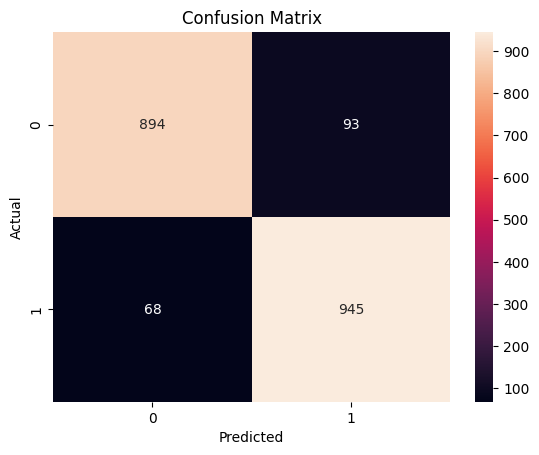

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
def predict_spam(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)
    return "Spam" if prediction[0] == 1 else "Ham"

In [32]:
print(predict_spam("Congratulations! You have won a free ticket"))
print(predict_spam("Hey, are we meeting today?"))

Spam
Ham


In [33]:
balanced_df.to_csv("balanced_spam_dataset.csv", index=False)